# Exploratory Data Analysis (EDA) on Retail Sales Data

## Objective
The objective of this project is to analyze retail sales data, identify trends, customer purchasing behavior, and generate actionable business insights through data visualization and statistical analysis.

## Author
Mohan Chandra
Data Analyst Intern - Oasis Infobyte

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [13]:
df=pd.read_csv("retail_sales_dataset.csv")

In [14]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


###LET US UNDERSTAND THE NATURE OF DATASET
####Here we performed some series of code blocks to understand and performed DATA CLEANING like we find that any NULL or DUPLICATE values are there or not .. and continued with creation of insights

In [15]:
df.shape

(1000, 9)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [17]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [18]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


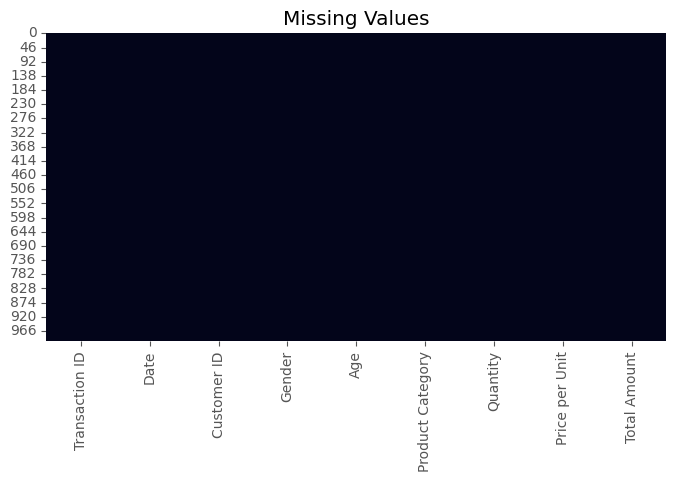

In [19]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Values")
plt.show()

In [20]:
df.duplicated().sum()

np.int64(0)

#DESCRIPTIVE STATISTICS

In [23]:
df.mean(numeric_only=True)


,0
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


In [24]:
df.median(numeric_only=True)


,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


In [25]:
df.std(numeric_only=True)

,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


#DATE CONVERSION

In [26]:
df['Date'] = pd.to_datetime(df['Date'])

In [27]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

##CUSTOMER ANALYSIS
######GENDER DISTRIBUTION

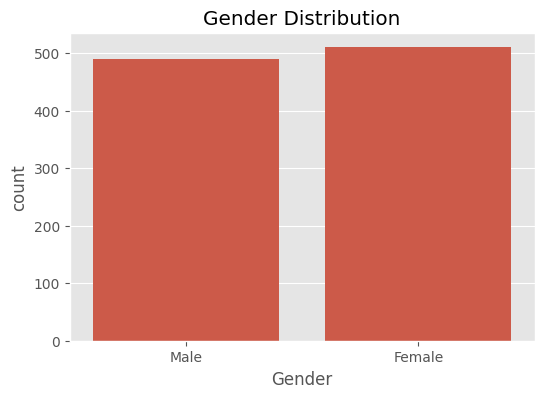

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender',data=df)
plt.title("Gender Distribution")
plt.show()

Female customers slightly greater than male customers.
######AGE DISTRIBUTION

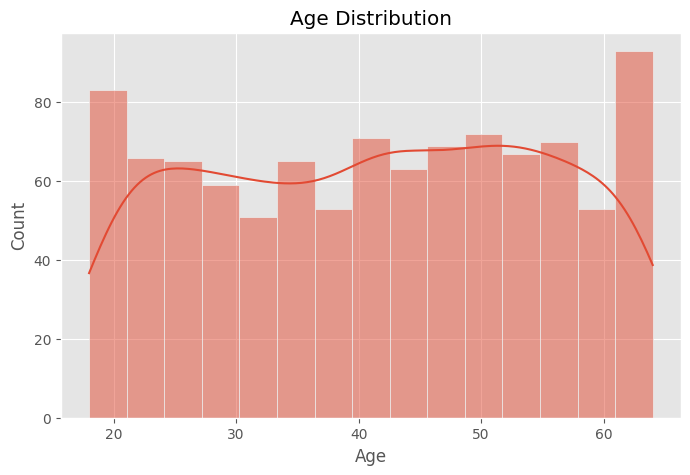

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'],bins=15,kde=True)
plt.title("Age Distribution")
plt.show()

Most customers belong to the age group of between 25 and 55 years.
##PRODUCT CATEGORY ANALYSIS

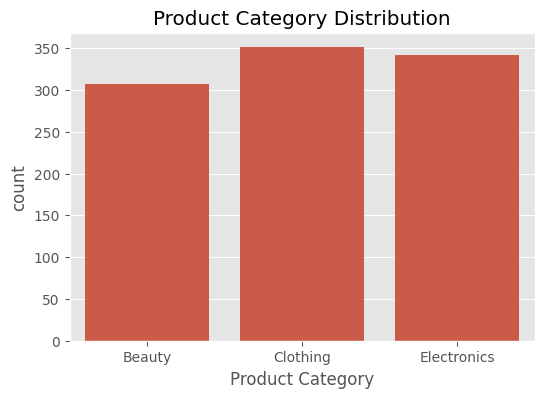

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Product Category',
    data=df
)

plt.title("Product Category Distribution")
plt.show()

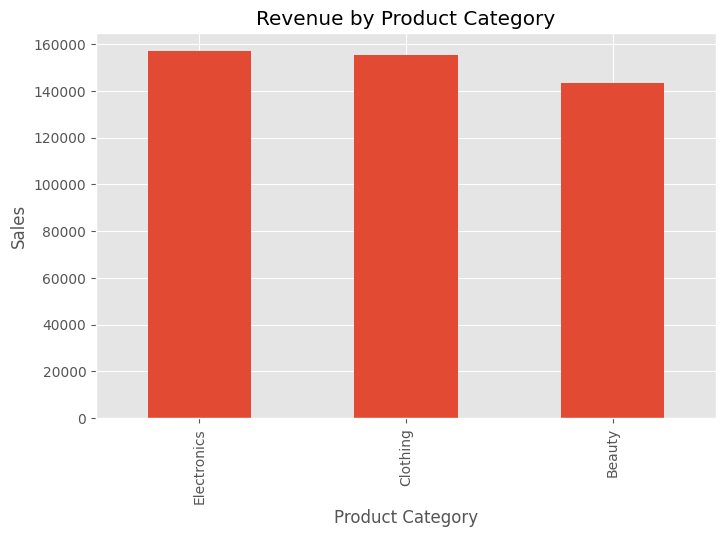

In [34]:
category_sales = df.groupby(
    'Product Category'
)['Total Amount'].sum()

category_sales.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Revenue by Product Category")
plt.ylabel("Sales")
plt.show()

The Electronics category generating the highest revenue contributes significantly to overall business performance.
##QUANTITY ANALYSIS

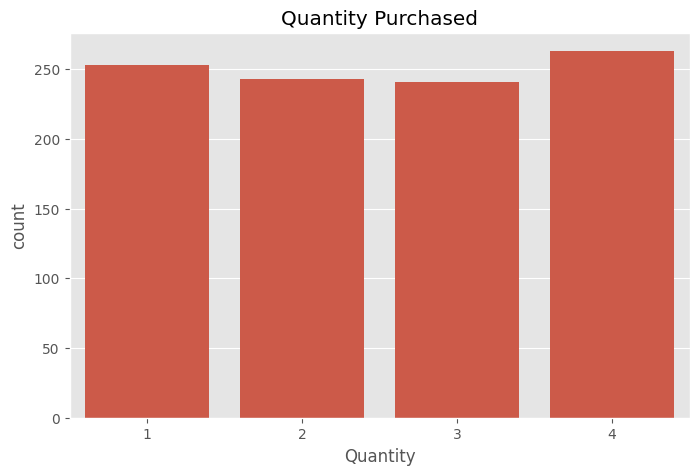

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Quantity',
    data=df
)

plt.title("Quantity Purchased")
plt.show()

#SALES TREND ANALYSIS
###MONTHLY SALES

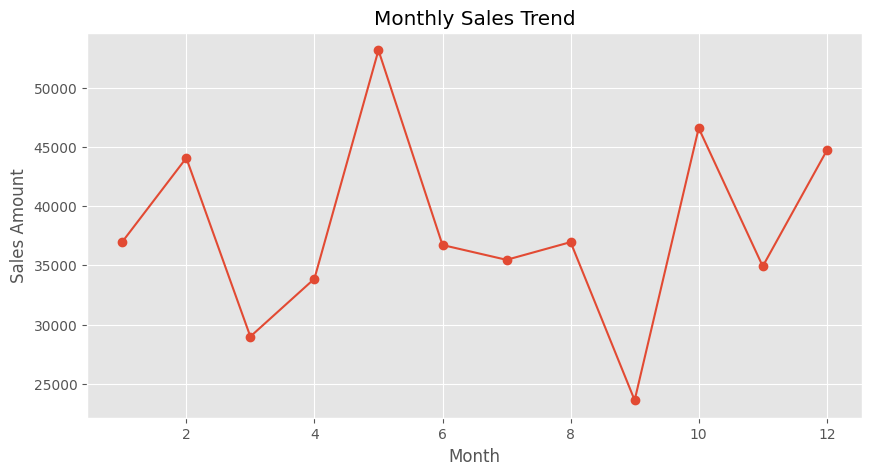

In [36]:
monthly_sales = df.groupby(
    'Month'
)['Total Amount'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.ylabel("Sales Amount")
plt.show()

Sales fluctuate across different months, indicating seasonal demand patterns. and onserved that at holiday season like MAY month have more contribution in sales
#TOP SPENDING GENDER

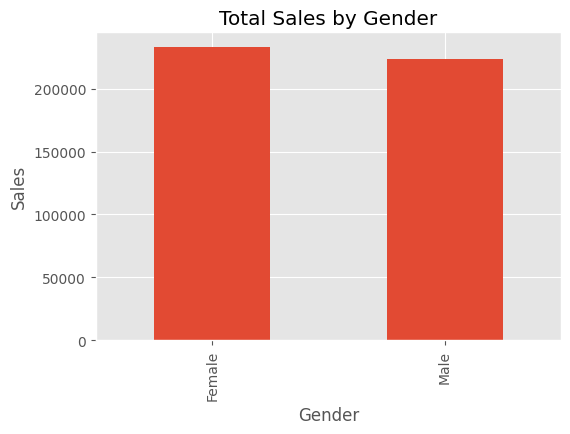

In [37]:
gender_sales = df.groupby(
    'Gender'
)['Total Amount'].sum()

gender_sales.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Total Sales by Gender")
plt.ylabel("Sales")
plt.show()

##AGE VS SPENDING & CORRELATION ANALYSIS USING HEAT MAP

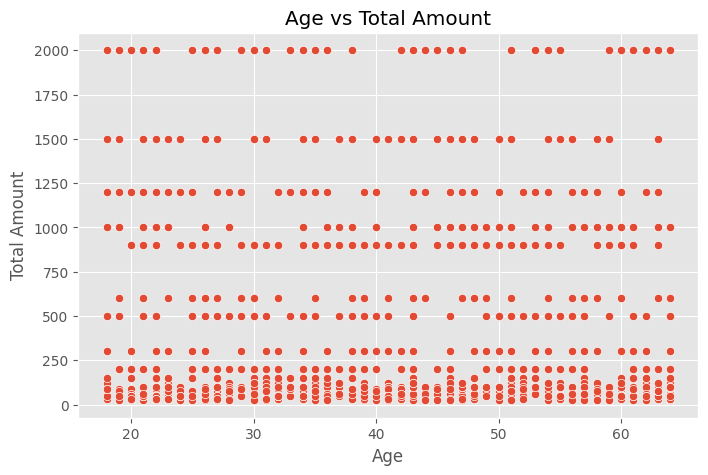

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Total Amount',
    data=df
)

plt.title("Age vs Total Amount")
plt.show()

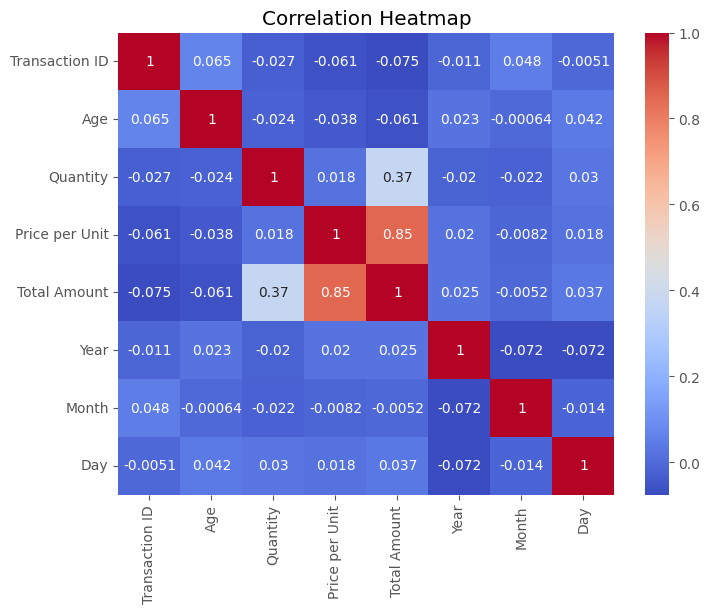

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

TOP 10 TRANSACTIONS

In [40]:
top_sales = df.nlargest(
    10,
    'Total Amount'
)

top_sales

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Day
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000,2023,1,16
64,65,2023-12-05,CUST065,Male,51,Electronics,4,500,2000,2023,12,5
71,72,2023-05-23,CUST072,Female,20,Electronics,4,500,2000,2023,5,23
73,74,2023-11-22,CUST074,Female,18,Beauty,4,500,2000,2023,11,22
88,89,2023-10-01,CUST089,Female,55,Electronics,4,500,2000,2023,10,1
92,93,2023-07-14,CUST093,Female,35,Beauty,4,500,2000,2023,7,14
108,109,2023-10-18,CUST109,Female,34,Electronics,4,500,2000,2023,10,18
117,118,2023-05-16,CUST118,Female,30,Electronics,4,500,2000,2023,5,16
123,124,2023-10-27,CUST124,Male,33,Clothing,4,500,2000,2023,10,27
138,139,2023-12-15,CUST139,Male,36,Beauty,4,500,2000,2023,12,15


#BUSINESS INSIGHTS
## Key Insights

1. Female customers represent a slightly larger customer base.

2. Customers aged between 25 and 55 contribute the majority of purchases.

3. Product categories show different revenue contributions.

4. Monthly sales reveal fluctuations indicating possible seasonal trends.

5. Quantity purchased has a positive relationship with total sales amount.

6. Higher-priced products contribute significantly to revenue.

7. Certain customer segments generate higher transaction values.

8. Sales performance can be improved by targeting high-value categories.

#Recommendations

1. Focus marketing campaigns on the highest-performing product categories.

2. Introduce loyalty programs for repeat customers.

3. Increase inventory for high-demand products.

4. Launch promotional campaigns during low-sales months.

5. Use customer demographics to create personalized offers.

6. Monitor sales trends regularly to improve forecasting accuracy.

7. Optimize pricing strategies for maximum profitability.

# Conclusion

The retail sales dataset was analyzed using Exploratory Data Analysis techniques. The analysis identified customer purchasing behavior, product performance, and sales trends. These insights can help businesses make informed decisions regarding marketing, inventory management, and customer engagement strategies.